# Configuración Inicial del Notebook

In [ ]:
# Instalación de librerías necesarias
!pip install -q pypdf # Para manejar PDFs (lectura, manipulación)
!pip install -q nltk  # Para procesamiento de lenguaje natural (tokenización, stopwords)
!pip install -q scikit-learn # Para algoritmos de machine learning (TF-IDF, KMeans, PCA)
!pip install -q azure-storage-blob # Para interactuar con Azure Blob Storage
!pip install -q joblib # Para guardar/cargar modelos scikit-learn como TfidfVectorizer
!pip install -q scipy  # Para guardar/cargar matrices dispersas

In [ ]:
# Función de preprocesamiento de texto
def preprocess_text(text):
    if not isinstance(text, str):
        return "" # Devolver una cadena vacía para valores no-string o None
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-záéíóúüñ\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text, language='spanish')
    stop_words_spanish = set(stopwords.words('spanish'))
    filtered_tokens = [word for word in tokens if word not in stop_words_spanish]

    return ' '.join(filtered_tokens)

print("Función `preprocess_text` definida.")

Función `preprocess_text` definida.


In [ ]:
# Importación de todas las librerías necesarias
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Para visualización como PCA
from pypdf import PdfReader
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans # Para K-Means
from sklearn.decomposition import PCA
from google.colab import userdata
from azure.storage.blob import BlobServiceClient
from io import BytesIO
import joblib # Necesario para cargar/guardar modelos scikit-learn como TfidfVectorizer
import scipy.sparse # Necesario para cargar/guardar matrices dispersas

In [ ]:
# Descargar recursos de NLTK (si no están ya descargados)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('punkt_tab')
except LookupError:
    print("Descargando 'punkt_tab' como sugiere el error de NLTK...")
    nltk.download('punkt_tab')

Descargando 'punkt_tab' como sugiere el error de NLTK...


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
# Configuración de Azure Blob Storage
account = userdata.get("AZURE_STORAGE_ACCOUNT")
sas = userdata.get("AZURE_STORAGE_SAS").lstrip("?")

service = BlobServiceClient(
    account_url=f"https://{account}.blob.core.windows.net",
    credential=sas,
)

source_container = service.get_container_client("ai-source-pdfs")
artifact_container = service.get_container_client("ai-artifacts")

print("Clientes de Azure Blob Storage configurados exitosamente.")

Clientes de Azure Blob Storage configurados exitosamente.


## Extracción de Texto de Documentos PDF

In [ ]:
# Extracción de texto de PDFs desde Azure Blob Storage

import warnings
from pypdf import PdfReader
from io import BytesIO

print(f"Buscando archivos PDF en el contenedor de origen de Azure Blob Storage.")

all_extracted_texts = {} # Diccionario para almacenar el texto de cada PDF
skipped_due_to_error = [] # Lista para almacenar archivos saltados por errores
skipped_due_to_no_text = [] # Lista para almacenar archivos sin texto extraído

for blob in source_container.list_blobs():
    if not blob.name.lower().endswith('.pdf'):
        continue

    document_identifier = blob.name # Usamos el nombre del blob como identificador
    print(f"\nProcesando archivo: {document_identifier}")
    try:
        # Convertir warnings de pypdf a errores para este bloque, si los hay.
        # Aunque pypdf suele usar PdfReadError para problemas críticos.
        with warnings.catch_warnings():
            # Si pypdf emite PdfReadWarning, esta línea lo elevaría como error.
            # Sin un equivalente directo en pypdf.errors, nos apoyamos en PdfReadError.
            # warnings.simplefilter('error', pypdf.errors.PdfReadWarning) # No existe directamente en pypdf.errors

            pdf_bytes = source_container.download_blob(blob.name).readall()
            pdf_bytes_io = BytesIO(pdf_bytes)
            reader = PdfReader(pdf_bytes_io)
            extracted_text = ''
            for page_num in range(len(reader.pages)):
                page = reader.pages[page_num]
                page_text = page.extract_text()
                if page_text:
                    extracted_text += page_text + '\n'

        if extracted_text:
            all_extracted_texts[document_identifier] = extracted_text
            print("Texto extraído exitosamente. Primeros 300 caracteres:")
            print(extracted_text[:300])
        else:
            print("No se encontró texto en este PDF.")
            skipped_due_to_no_text.append(document_identifier) # Añadir a la lista de saltados

    except pypdf.errors.PdfReadError as e:
        print(f"Error de lectura de PDF con '{document_identifier}': {e}. Podría estar encriptado o corrupto. Saltando.")
        skipped_due_to_error.append(document_identifier) # Añadir a la lista de saltados
    except Exception as e:
        print(f"Ocurrió un error inesperado con '{document_identifier}': {e}. Saltando.")
        skipped_due_to_error.append(document_identifier) # Añadir a la lista de saltados

print("\n--- Resumen de Textos Extraídos ---")
print(f"Número total de textos extraídos: {len(all_extracted_texts)}")
for identifier, text in all_extracted_texts.items():
    print(f"Archivo: {identifier}, Longitud del texto: {len(text)} caracteres")

if skipped_due_to_error:
    print("\n--- Archivos Saltados por Errores ---")
    for identifier in skipped_due_to_error:
        print(identifier)
if skipped_due_to_no_text:
    print("\n--- Archivos Saltados por No Contener Texto ---")
    for identifier in skipped_due_to_no_text:
        print(identifier)

print("\nNota: Cualquier problema crítico durante la lectura de un PDF usando pypdf ahora resultará en que el archivo sea saltado y listado bajo 'Archivos Saltados por Errores'.")

Buscando archivos PDF en el contenedor de origen de Azure Blob Storage.

Procesando archivo: IIFHCE_Libros/Desigualdades en una universidad p blica bolivian1530.pdf
Texto extraído exitosamente. Primeros 300 caracteres:
Universidad Mayor de San Simón
Facultad de Humanidades y Ciencias de la Educación
Instituto de Investigaciones “Juan Araos Úzqueda”
 
 
Desigualdades en una universidad pública 
boliviana
 
 
 
 
 
 
 
 
Jorge Antonio Mayorga Lazcano
Universidad Mayor de San Simón
Facultad de Humanidades y Ciencias 

Procesando archivo: IIFHCE_Libros/Estado de situaci n de la Universidad Mayor de Sa1822.pdf
Texto extraído exitosamente. Primeros 300 caracteres:
Guido C. Machaca Benito 
(Coordinador)
ESTADO DE SITUACIÓN DE LA
UNIVERSIDAD MAYOR DE SAN SIMÓN
FRENTE A SUS DESAFÍOS ACADÉMICOS
E INSTITUCIONALES

Estado de situación de la 
Universidad Mayor de San Simón 
frente a sus desafíos académicos 
e institucionales
Guido C. Machaca Benito 
(Coordinador)

©

Procesando archivo: IIFHCE_Libr

## Creación del DataFrame de Documentos y Metadatos

In [ ]:
# Convertir el diccionario de textos extraídos a un DataFrame de pandas
data = []
for path, text in all_extracted_texts.items():
    data.append({'document_path': path, 'text_content': text})

df_documents = pd.DataFrame(data)

# Extraer el título del documento del document_path (que ahora es el nombre del blob)
df_documents['document_title'] = df_documents['document_path'].apply(lambda x: x.replace('.pdf', '').replace('+', ' ').strip())

# Calcular el número de palabras en el texto de cada documento
df_documents['document_words'] = df_documents['text_content'].apply(lambda x: len(x.split()))

# Mostrar las dimensiones del DataFrame
print(f"Dimensiones del DataFrame: {df_documents.shape}")
print(f"Número de documentos: {df_documents.shape[0]}")

# Mostrar todas las filas del DataFrame con el título y el conteo de palabras
print("\nDataFrame completo con el título y el conteo de palabras (primeras 5 filas):")
display(df_documents[['document_title', 'document_words', 'text_content']].head())

Dimensiones del DataFrame: (16, 4)
Número de documentos: 16

DataFrame completo con el título y el conteo de palabras (primeras 5 filas):


,document_title,document_words,text_content
0,IIFHCE_Libros/Desigualdades en una universidad...,17877,Universidad Mayor de San Simón\nFacultad de Hu...
1,IIFHCE_Libros/Estado de situaci n de la Univer...,55869,Guido C. Machaca Benito \n(Coordinador)\nESTAD...
2,IIFHCE_Libros/Extensi n universitaria o intera...,42770,Universidad Mayor de San Simón\nFacultad de Hu...
3,IIFHCE_Libros/Gu a para la presentaci n escrit...,6216,UNIVERSIDAD MAYOR DE SAN SIMÓN \nFACULTAD DE H...
4,IIFHCE_Libros/La m sica boliviana en la segund...,32649,Universidad Mayor de San Simón\nFacultad de Hu...


## Guardar y Cargar el DataFrame Procesado (Opcional, para reutilización)

In [ ]:
# Guardar el DataFrame con el texto extraído y metadatos en un archivo CSV en Azure Blob Storage

csv_bytes = df_documents.to_csv(index=False).encode("utf-8")

artifact_container.upload_blob(
    name="processed_documents.csv",
    data=csv_bytes,
    overwrite=True,
)

print(f"DataFrame guardado exitosamente en el contenedor de artefactos de Azure como 'processed_documents.csv'.")

DataFrame guardado exitosamente en el contenedor de artefactos de Azure como 'processed_documents.csv'.


In [ ]:
# Guardar los artefactos de TF-IDF en Azure Blob Storage para futuras sesiones

import joblib
import scipy.sparse # Para guardar la matriz dispersa
from io import BytesIO

print("Guardando tfidf_vectorizer y X_tfidf en Azure Blob Storage...")

# 1. Guardar tfidf_vectorizer
vectorizer_bytes_io = BytesIO()
joblib.dump(tfidf_vectorizer, vectorizer_bytes_io)
vectorizer_bytes_io.seek(0) # Volver al inicio del stream
artifact_container.upload_blob(
    name="tfidf_vectorizer.joblib",
    data=vectorizer_bytes_io.read(),
    overwrite=True,
)
print("tfidf_vectorizer guardado exitosamente.")

# Guardar la matriz dispersa a un archivo temporal en memoria y luego subir sus bytes
sparse_matrix_bytes_io = BytesIO()
scipy.sparse.save_npz(sparse_matrix_bytes_io, X_tfidf)
sparse_matrix_bytes_io.seek(0)
artifact_container.upload_blob(
    name="X_tfidf.npz",
    data=sparse_matrix_bytes_io.read(),
    overwrite=True,
)
print("X_tfidf (matriz dispersa) guardado exitosamente.")

print("Artefactos de TF-IDF guardados exitosamente en Azure Blob Storage.")

Guardando tfidf_vectorizer y X_tfidf en Azure Blob Storage...
tfidf_vectorizer guardado exitosamente.
X_tfidf (matriz dispersa) guardado exitosamente.
Artefactos de TF-IDF guardados exitosamente en Azure Blob Storage.


In [ ]:
# Cargar el DataFrame desde el archivo CSV en Azure Blob Storage en una nueva sesión

import io

# Descargar el blob del CSV
csv_blob_client = artifact_container.get_blob_client("processed_documents.csv")
csv_bytes = csv_blob_client.download_blob().readall()

# Leer el CSV en un DataFrame de pandas
df_documents_loaded = pd.read_csv(io.BytesIO(csv_bytes))

print(f"DataFrame cargado exitosamente. Dimensiones: {df_documents_loaded.shape}")
print("Primeras 5 filas del DataFrame cargado:")
display(df_documents_loaded.head())

DataFrame cargado exitosamente. Dimensiones: (16, 4)
Primeras 5 filas del DataFrame cargado:


,document_path,text_content,document_title,document_words
0,IIFHCE_Libros/Desigualdades en una universidad...,Universidad Mayor de San Simón\nFacultad de Hu...,IIFHCE_Libros/Desigualdades en una universidad...,17877
1,IIFHCE_Libros/Estado de situaci n de la Univer...,Guido C. Machaca Benito \n(Coordinador)\nESTAD...,IIFHCE_Libros/Estado de situaci n de la Univer...,55869
2,IIFHCE_Libros/Extensi n universitaria o intera...,Universidad Mayor de San Simón\nFacultad de Hu...,IIFHCE_Libros/Extensi n universitaria o intera...,42770
3,IIFHCE_Libros/Gu a para la presentaci n escrit...,UNIVERSIDAD MAYOR DE SAN SIMÓN \nFACULTAD DE H...,IIFHCE_Libros/Gu a para la presentaci n escrit...,6216
4,IIFHCE_Libros/La m sica boliviana en la segund...,Universidad Mayor de San Simón\nFacultad de Hu...,IIFHCE_Libros/La m sica boliviana en la segund...,32649


In [ ]:
# Cargar los artefactos de TF-IDF desde Azure Blob Storage en una nueva sesión

import joblib
import scipy.sparse
from io import BytesIO

print("Cargando tfidf_vectorizer y X_tfidf desde Azure Blob Storage...")

# 1. Cargar tfidf_vectorizer
vectorizer_blob_client = artifact_container.get_blob_client("tfidf_vectorizer.joblib")
vectorizer_bytes = vectorizer_blob_client.download_blob().readall()
vectorizer_loaded = joblib.load(BytesIO(vectorizer_bytes))
print("tfidf_vectorizer cargado exitosamente.")

# 2. Cargar X_tfidf (matriz dispersa)
sparse_matrix_blob_client = artifact_container.get_blob_client("X_tfidf.npz")
sparse_matrix_bytes = sparse_matrix_blob_client.download_blob().readall()
X_tfidf_loaded = scipy.sparse.load_npz(BytesIO(sparse_matrix_bytes))
print("X_tfidf (matriz dispersa) cargado exitosamente.")

print("Artefactos de TF-IDF cargados exitosamente.")

# print(f"Tipo de vectorizador cargado: {type(vectorizer_loaded)}")
# print(f"Dimensiones de X_tfidf cargado: {X_tfidf_loaded.shape}")

Cargando tfidf_vectorizer y X_tfidf desde Azure Blob Storage...
tfidf_vectorizer cargado exitosamente.
X_tfidf (matriz dispersa) cargado exitosamente.
Artefactos de TF-IDF cargados exitosamente.


## Pipeline de Procesamiento NLP

### 1. Preprocesamiento de Texto (Limpieza, Tokenización, Stop Words)

In [ ]:
# Aplicar la función de preprocesamiento para crear la columna 'cleaned_text' en el DataFrame cargado
df_documents_loaded['cleaned_text'] = df_documents_loaded['text_content'].apply(preprocess_text)

print("Texto original del primer documento (df_documents_loaded):")
print(df_documents_loaded['text_content'].iloc[0][:500])
print("\nTexto preprocesado del primer documento (df_documents_loaded, primeros 500 caracteres):")
print(df_documents_loaded['cleaned_text'].iloc[0][:500])
display(df_documents_loaded.head())

Texto original del primer documento (df_documents_loaded):
Universidad Mayor de San Simón
Facultad de Humanidades y Ciencias de la Educación
Instituto de Investigaciones “Juan Araos Úzqueda”
 
 
Desigualdades en una universidad pública 
boliviana
 
 
 
 
 
 
 
 
Jorge Antonio Mayorga Lazcano
Universidad Mayor de San Simón
Facultad de Humanidades y Ciencias de la Educación
© Instituto de Investigaciones de la Facultad de Humanidades y Ciencias de la Educación
© Editorial Humanidades
©  Jorge Antonio Mayorga Lazcano
Decano: J. Gunnar Zapata Zurita
Directo

Texto preprocesado del primer documento (df_documents_loaded, primeros 500 caracteres):
universidad mayor san simón facultad humanidades ciencias educación instituto investigaciones juan araos úzqueda desigualdades universidad pública boliviana jorge antonio mayorga lazcano universidad mayor san simón facultad humanidades ciencias educación instituto investigaciones facultad humanidades ciencias educación editorial humanidades jorge an

,document_path,text_content,document_title,document_words,cleaned_text
0,IIFHCE_Libros/Desigualdades en una universidad...,Universidad Mayor de San Simón\nFacultad de Hu...,IIFHCE_Libros/Desigualdades en una universidad...,17877,universidad mayor san simón facultad humanidad...
1,IIFHCE_Libros/Estado de situaci n de la Univer...,Guido C. Machaca Benito \n(Coordinador)\nESTAD...,IIFHCE_Libros/Estado de situaci n de la Univer...,55869,guido c machaca benito coordinador situación u...
2,IIFHCE_Libros/Extensi n universitaria o intera...,Universidad Mayor de San Simón\nFacultad de Hu...,IIFHCE_Libros/Extensi n universitaria o intera...,42770,universidad mayor san simón facultad humanidad...
3,IIFHCE_Libros/Gu a para la presentaci n escrit...,UNIVERSIDAD MAYOR DE SAN SIMÓN \nFACULTAD DE H...,IIFHCE_Libros/Gu a para la presentaci n escrit...,6216,universidad mayor san simón facultad humanidad...
4,IIFHCE_Libros/La m sica boliviana en la segund...,Universidad Mayor de San Simón\nFacultad de Hu...,IIFHCE_Libros/La m sica boliviana en la segund...,32649,universidad mayor san simón facultad humanidad...


### 2. Vectorización del Texto (TF-IDF)

In [ ]:
# Utilizar el vectorizador TF-IDF y la matriz dispersa cargada desde Azure Blob Storage
# La matriz X_tfidf_loaded y el vectorizador vectorizer_loaded ya fueron cargados previamente.

print(f"Dimensiones de la matriz TF-IDF cargada: {X_tfidf_loaded.shape}")
print("\nPrimeras 50 características (palabras) del vocabulario TF-IDF del vectorizador cargado:\n", vectorizer_loaded.get_feature_names_out()[:50])

Dimensiones de la matriz TF-IDF cargada: (16, 5000)

Primeras 50 características (palabras) del vocabulario TF-IDF del vectorizador cargado:
 ['aa' 'aab' 'aad' 'ab' 'aba' 'abandonadas' 'abandonan' 'abandonar'
 'abandonaron' 'abandono' 'abarca' 'abarcan' 'abarcando' 'abc' 'abierta'
 'abiertas' 'abierto' 'aborda' 'abordadas' 'abordado' 'abordados'
 'abordaje' 'abordan' 'abordando' 'abordar' 'abre' 'abren' 'abril' 'abrir'
 'abrió' 'absoluta' 'absolutos' 'abud' 'abuelos' 'abuso' 'ac' 'aca' 'acad'
 'academia' 'académica' 'académicas' 'académico' 'académicos' 'acc'
 'acceden' 'acceder' 'accesibilidad' 'accesible' 'acceso' 'accionar']


### 3. Modelado (Ejemplo: Clustering con K-Means)

In [ ]:
from sklearn.cluster import KMeans

# Definir el número de clusters
num_clusters = 3 # Puedes ajustar este valor según tus datos y necesidades

# Inicializar y ajustar el modelo K-Means utilizando la matriz TF-IDF cargada
kmeans_model = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
df_documents_loaded['cluster'] = kmeans_model.fit_predict(X_tfidf_loaded)

print(f"Distribución de documentos por cluster:\n{df_documents_loaded['cluster'].value_counts()}")
print("\nPrimeras 5 filas con la asignación de cluster:")
display(df_documents_loaded[['document_title', 'cluster']].head())

Distribución de documentos por cluster:
cluster
0    12
2     3
1     1
Name: count, dtype: int64

Primeras 5 filas con la asignación de cluster:


,document_title,cluster
0,IIFHCE_Libros/Desigualdades en una universidad...,0
1,IIFHCE_Libros/Estado de situaci n de la Univer...,0
2,IIFHCE_Libros/Extensi n universitaria o intera...,0
3,IIFHCE_Libros/Gu a para la presentaci n escrit...,0
4,IIFHCE_Libros/La m sica boliviana en la segund...,0


### 4. Visualización de Resultados

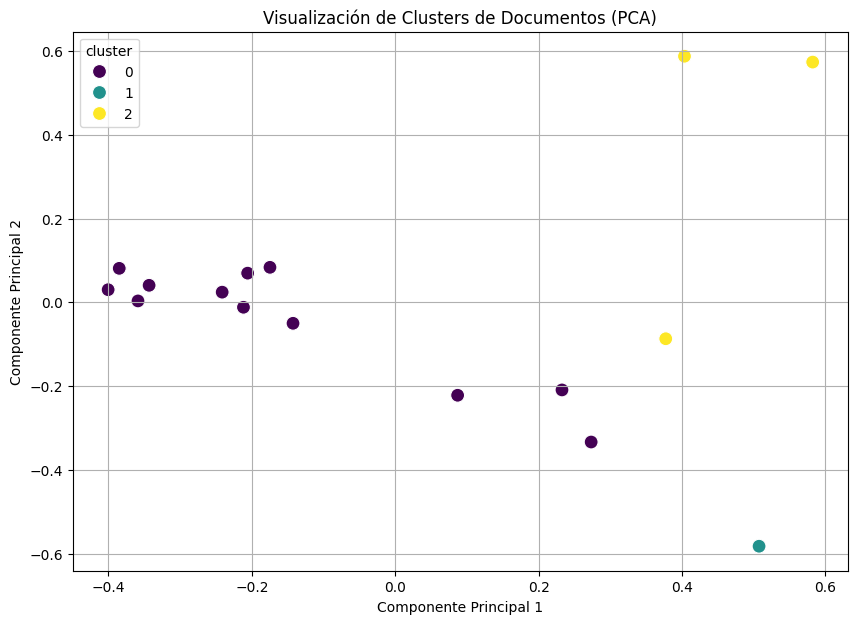

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns # Importamos seaborn

# Reducir la dimensionalidad con PCA a 2 componentes, utilizando la matriz TF-IDF cargada
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf_loaded.toarray()) # K-Means y PCA trabajan con matrices densas

# Crear un DataFrame para la visualización
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = df_documents_loaded['cluster']

# Visualizar los clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="cluster",
    data=df_pca,
    palette='viridis',
    legend='full',
    s=100
)
plt.title('Visualización de Clusters de Documentos (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()

### 1. Re-inicialización de Componentes NLP para el Motor de Búsqueda


## Motor de Búsqueda NLP Basado en Similitud

In [123]:
# Se asume que `preprocess_text`, `X_tfidf_loaded`, `vectorizer_loaded` y `df_documents_loaded` están definidos

def search_documents(query, df, tfidf_matrix, vectorizer, top_n=5):
    cleaned_query = preprocess_text(query)
    query_vector = vectorizer.transform([cleaned_query])
    cosine_similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
    related_docs_indices = cosine_similarities.argsort()[:-top_n-1:-1]

    results = []
    for i in related_docs_indices:
        results.append({
            'document_title': df['document_title'].iloc[i],
            'similarity_score': cosine_similarities[i],
            'document_path': df['document_path'].iloc[i]
        })
    return pd.DataFrame(results)

# Ejemplo #1 de uso del motor de búsqueda, utilizando los artefactos cargados:
query = "educacion superior universidades"
print(f"\nBuscando documentos relacionados con: '{query}'\n")
search_results = search_documents(query, df_documents_loaded, X_tfidf_loaded, vectorizer_loaded, top_n=1)
display(search_results)

# Ejemplo #2 de uso del motor de búsqueda, utilizando los artefactos cargados:
query_2 = "salud mental VIH"
print(f"\nBuscando documentos relacionados con: '{query_2}'\n")
search_results_2 = search_documents(query_2, df_documents_loaded, X_tfidf_loaded, vectorizer_loaded, top_n=2)
display(search_results_2)

# Ejemplo #3 de uso del motor de búsqueda, utilizando los artefactos cargados:
query_3 = "materias"
print(f"\nBuscando documentos relacionados con: '{query_3}'\n")
search_results_3 = search_documents(query_3, df_documents_loaded, X_tfidf_loaded, vectorizer_loaded, top_n=5)
display(search_results_3)


Buscando documentos relacionados con: 'educacion superior universidades'



,document_title,similarity_score,document_path
0,IIFHCE_Libros/Extensi n universitaria o intera...,0.039492,IIFHCE_Libros/Extensi n universitaria o intera...



Buscando documentos relacionados con: 'salud mental VIH'



,document_title,similarity_score,document_path
0,IIFHCE_Libros/Extensi n universitaria o intera...,0.026336,IIFHCE_Libros/Extensi n universitaria o intera...
1,IIFHCE_Libros/RASTREANDO LAS HUELLAS DE LA VIO...,0.023932,IIFHCE_Libros/RASTREANDO LAS HUELLAS DE LA VIO...



Buscando documentos relacionados con: 'materias'



,document_title,similarity_score,document_path
0,IIFHCE_Libros/Desigualdades en una universidad...,0.181357,IIFHCE_Libros/Desigualdades en una universidad...
1,IIFHCE_Libros/Estado de situaci n de la Univer...,0.054014,IIFHCE_Libros/Estado de situaci n de la Univer...
2,IIFHCE_Libros/formacion_e_investigacion,0.046444,IIFHCE_Libros/formacion_e_investigacion.pdf
3,IIFHCE_Libros/nuevos_escenarios_nuevos_desafios,0.029497,IIFHCE_Libros/nuevos_escenarios_nuevos_desafio...
4,IIFHCE_Libros/Permanencia estudiantil y modali...,0.014018,IIFHCE_Libros/Permanencia estudiantil y modali...
